# 10-1. 차원축소

고차원의 데이터는 계산비용의 증가, 다중공선성 문제(Feature간 같은 정보를 가질 때)를 일으킬 수 있음.  
차원축소는 데이터의 노이즈를 줄이고, 더 좋은 학습결과를 얻을 수 있으며(중요한 특징만을 선별하여 모델링에 사용함으로써),  
데이터를 다루기 쉬워지고, 결과 이해가 쉬워짐

- Feature selection: 유용한 특성만 선별하여 사용
- Feature extraction: 기존 특성을 활용하여 새로운 특성 생성
  * PCA, LSA(=Truncated SVD), 요인분석(FA), 독립성분석(ICA), 음수 미포함 행렬 분해(NMF), 다차원척도법(MDS), t-SNE
- Clustering: 더 적은 수의 특성 사용

## 주성분분석
주성분분석(Principal Component Analysis, PCA)은 고차원 데이터를 더 적은 차원으로 축소하면서도 데이터의 **핵심적인 정보(분산)** 를   
최대한 보존하려는 통계 기법, 각 특징이 정규분포를 따른다고 가정하므로 스케일링이 필요

<장단점>
- 장점: 
  - 차원 축소: 많은 특성(feature)을 가진 데이터를 더 적은 수의 특성으로 요약해 계산 효율을 높이고, 과적합(overfitting) 방지
  - 시각화: 고차원 데이터를 2D 또는 3D로 줄여 시각적으로 이해하기 쉽게 만듬
  - 노이즈 제거: 중요하지 않은 축(분산이 적은 축)을 제거하면서 데이터의 잡음을 줄임
- 단점: 결과의 해석이 어려움, 데이터의 비선형 구조 반영 불가

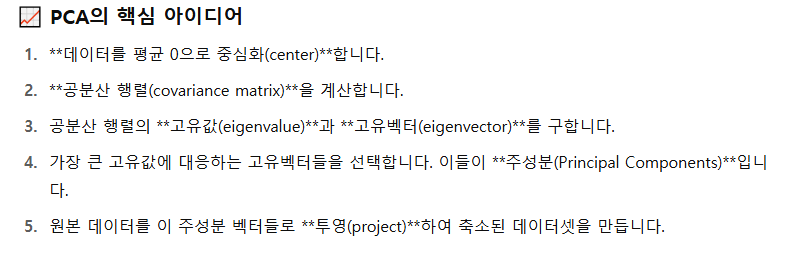

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from sklearn.datasets import load_wine
from collections import Counter
from sklearn.model_selection import train_test_split
import koreanize_matplotlib

warnings.filterwarnings('ignore')

X = pd.DataFrame(load_wine().data, columns=load_wine().feature_names)
Y = load_wine().target

print(f"feature 개수: {X.shape[1]}")

# 데이터분할: test 데이터의 정보를 학습에 사용하면 안 되기 때문에
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42, stratify=Y)

#데이터표준화: PCA 전 필수
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
col_list = X.columns

s_train_X = pd.DataFrame(sc.fit_transform(train_X), columns=col_list)
s_test_X = pd.DataFrame(sc.transform(test_X), columns=col_list)

#PCA 적합
from sklearn.decomposition import PCA

pca = PCA(n_components=X.shape[1], svd_solver='auto') #전체 feature 수 입력
pca.fit(s_train_X)

#고윳값 요약
e_value = pd.DataFrame({'feat': ["comp_" + str(i) for i in range(1, X.shape[1]+1)], 
                        '고윳값': pca.explained_variance_, 
                        '기여율': pca.explained_variance_ratio_, 
                        '누적기여율': pca.explained_variance_ratio_.cumsum()})

display(e_value) 

#scree plot
plt.figure(figsize=(15, 8))
sns.lineplot(x=e_value.index+1, y='고윳값', data=e_value, marker='o')
plt.title('Scree plot')
plt.axvline(x=5, color='r', linestyle='--')
plt.show()

feature 개수: 13


,feat,고윳값,기여율,누적기여율
0,comp_1,4.682698,0.357499,0.357499
1,comp_2,2.516121,0.192093,0.549592
2,comp_3,1.420611,0.108456,0.658048
3,comp_4,0.971689,0.074183,0.732231
4,comp_5,0.908467,0.069357,0.801588
5,comp_6,0.681526,0.052031,0.853619
6,comp_7,0.575217,0.043915,0.897534
7,comp_8,0.327535,0.025006,0.922539
8,comp_9,0.288438,0.022021,0.944560
9,comp_10,0.250971,0.019160,0.963720


<Figure size 1500x800 with 1 Axes>

- 행: PCA로 만들어진 주성분 축
- 열: 기존 feature
- 값: 해당 주성분이 원래 변수에 대해 얼마나 **기여 또는 영향(기울기)** 을 받는지 나타냄. 즉, 가중치 계수(loading)

부호는 해당 변수의 기여 방향성을 나타내며, 절대값이 클 수 록 그 변수는 주성분의 생성에 크게 기여함

In [2]:
#차원축소
pca = PCA(n_components=0.8, svd_solver='auto') #개수로도 가능 5, 데이터 분산의 약 80%를 설명하는 데이터로 다시 재구성
rs = pca.fit_transform(s_train_X)

#생성된 PCA 결과
display(pd.DataFrame(rs, columns=["comp"+str(i) for i in range(1, rs.shape[1]+1)]).head(3))

# 고유벡터 요약
e_vector = pd.DataFrame(pca.components_, 
                        index=["comp"+str(i) for i in range(1, rs.shape[1]+1)], 
                       columns=X.columns)
e_vector

,comp1,comp2,comp3,comp4,comp5
0,-2.626186,-0.964018,1.657844,-0.677975,-0.745447
1,-0.487640,2.100956,0.545189,0.014953,-0.544125
2,-1.446727,-0.757399,-0.400605,-1.047839,0.617330


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
comp1,-0.154343,0.237366,0.010167,0.237380,-0.138307,-0.392694,-0.427807,0.281837,-0.310834,0.093892,-0.303514,-0.381598,-0.290557
comp2,-0.485829,-0.197082,-0.332664,0.024794,-0.293692,-0.069563,0.001877,-0.013360,-0.002984,-0.525169,0.286818,0.171476,-0.367551
comp3,0.131406,-0.096333,-0.620770,-0.630688,-0.072165,-0.172709,-0.131239,-0.189598,-0.179042,0.149568,-0.117994,-0.131903,0.127969
comp4,-0.205288,0.491547,-0.225973,0.106686,0.296142,0.032601,0.039091,-0.500597,0.354413,-0.024982,-0.362719,0.060969,-0.226691
comp5,-0.187588,-0.375260,0.051747,0.049257,0.761066,-0.239022,-0.210354,-0.150294,-0.076593,-0.100850,0.220782,-0.216644,0.063088


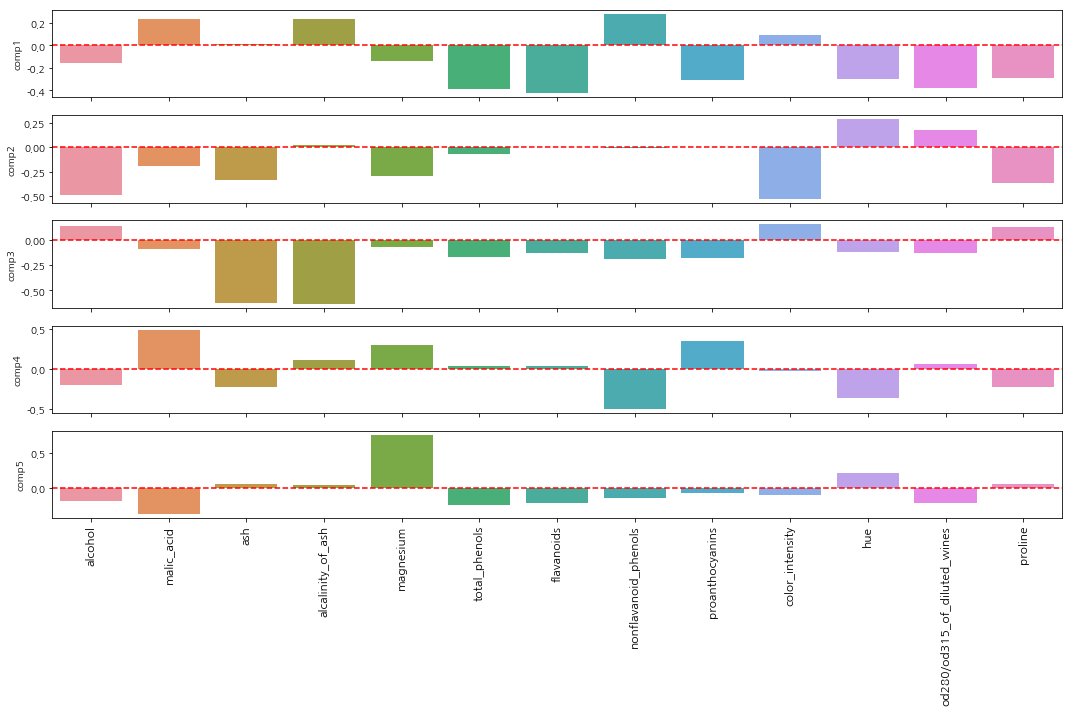

In [3]:
fig, ax = plt.subplots(rs.shape[1], 1, figsize=(15, 10))

for i, idx in enumerate(e_vector.index):
    sns.barplot(x=e_vector.columns, y=e_vector.iloc[i], ax=ax[i])
    ax[i].axhline(y=0, color='r', linestyle='--')
    if i != 4:
        ax[i].set_xticklabels([])
    else:
        ax[i].set_xticklabels(list(e_vector.columns), rotation=90, fontsize=12)
plt.tight_layout()
plt.show()

biplot을 통한 pca 결과 해석
1. 각 pc축에 가깝게 평행을 이루는 변수가 해당 pc에 가장 영향을 많이 주는 변수
2. 각 빨간선의 길이는 원 변수의 분산을 표현, 길이가 길수록 분산이 큼
3. 각 빨간선이 가까울수록 서로 상관관계가 있음

아래 결과는 PC1은 기존 데이터에서 36.4%의 분산설명률을 가지고 있고, PC2는 18.6%의 설명률을 가지고 있다.  
ash 등 PC2와 평행을 이루는 변수가 PC2에 많은 영향을 주고 있으며, ash와 alcohol과 빨간선이 가까우므로 서로 상관관계가 있는 것으로  
관찰된다. alcohol보다 ash가 화살표가 짧으므로 작은 분산을 가진다고 볼 수 있다.

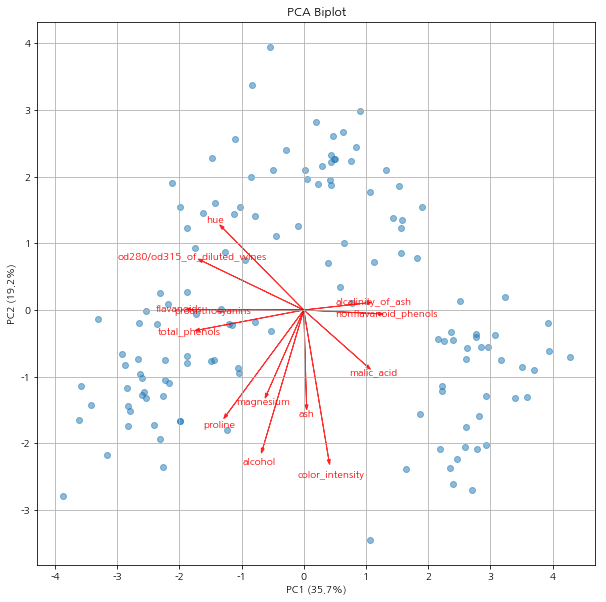

In [4]:
#biplot을 통한 pca 결과 해석: 지원x

# 변수 이름 (열 이름)
features = s_train_X.columns

# Biplot 그리기
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1. 샘플 점수 시각화
ax.scatter(rs[:, 0], rs[:, 1], alpha=0.5)

# 2. 변수 벡터 시각화
for i, feature in enumerate(features):
    vector = pca.components_[:, i] * max(rs[:, 0].max(), rs[:, 1].max())  # 스케일 맞추기
    ax.arrow(0, 0, vector[0], vector[1], color='r', alpha=0.8, head_width=0.05)
    ax.text(vector[0]*1.1, vector[1]*1.1, feature, color='r', ha='center', va='center', fontsize=10)

# 축 라벨
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA Biplot")

plt.grid()
plt.show()

## 요인분석

변수들 간의 상관관계를 분석하여 공통 차원들을 통해 축약하는 통계기법으로 다수 변수들의 정보 손실을 최소화하면서 소수의 요인으로 축약  
잠재변수에 대해 연결된 분산을 찾고, 오차를 추가한 인자들의 선형결합으로 관측된 변수들을 표현  
FA의 잠재변수들은 기본적으로 대등한 관계(PCA는 다른성분보다 중요한 변수가 있음)   
- 탐색적 요인분석(EFA): 변수가 어느 요인에 부합될지에 대한 가설이 없을 시
- 확인요인분석(CFA): 변수와 요인에 대한 특정한 가설을 토대로 요인 분석모델과 자료가 부합하는지 확인할 때

요인분석을 통해 변수축소(여러 개의 관련있는 변수들이 하나의 요인으로 묶임), 불필요한 변수 제거(요인에 포함되지 않거나 포함되더라도  
중요도가 낮은 변수를 찾을 수 있음), 변수특성파악(관련된 변수들이 묶임으로써 요인들의 상호독립적인 특성을 파악), 요인점수를 이용한  
변수생성을 할 수 있음

| 항목                                | 의미                                                          |
| --------------------------------- | ----------------------------------------------------------- |
| **행** (`latent1`, ..., `latent5`) | 잠재 요인 (Factor 1\~5)                                         |
| **열** (`alcohol`, ..., `proline`) | 원래 변수                                                       |
| **값**                             | 해당 요인이 변수에 미치는 영향력 (factor loading). **값의 절댓값이 클수록 중요한 기여** |

- latent1: total_phenols, flavanoids,od280/od315 등이 강하게 작용 → 해당변수는 와인의 복합성, 구조감, 바디감 관련 요인

In [5]:
# 위 데이터 그대로 사용

print(f"feature {X.shape[1]} 개, 데이터 {X.shape[0]} 개")

#스케일링한 데이터도 그대로 사용
#FA 적합
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=5) # 개수로 지정 가능
fa_rs = fa.fit_transform(s_train_X)


#각 잠재요인의 feature별 최대분산
max_var = pd.DataFrame(fa.components_, index=['latent'+str(i) for i in range(1, fa_rs.shape[1]+1)], columns=X.columns)
display(max_var)

feature 13 개, 데이터 178 개


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
latent1,-0.316411,0.417331,-0.074310,0.413285,-0.230766,-0.869186,-0.971660,0.527684,-0.653558,0.193486,-0.610866,-0.804935,-0.567109
latent2,-0.578325,-0.249297,-0.727555,-0.185387,-0.540497,-0.092921,0.018971,-0.072849,-0.005178,-0.663413,0.357523,0.244888,-0.465758
latent3,0.309860,-0.048018,-0.560599,-0.645475,0.291990,-0.035991,-0.049312,-0.267291,0.022115,0.326265,-0.173745,-0.114288,0.344410
latent4,-0.280033,-0.187664,0.008527,0.096746,0.619492,-0.095266,-0.077111,-0.119359,0.072817,-0.359838,0.350041,0.028253,-0.048264
latent5,-0.226182,0.271470,-0.112340,0.229963,0.159814,0.100422,0.067363,-0.202494,0.284493,0.050628,-0.390110,0.010402,-0.318126


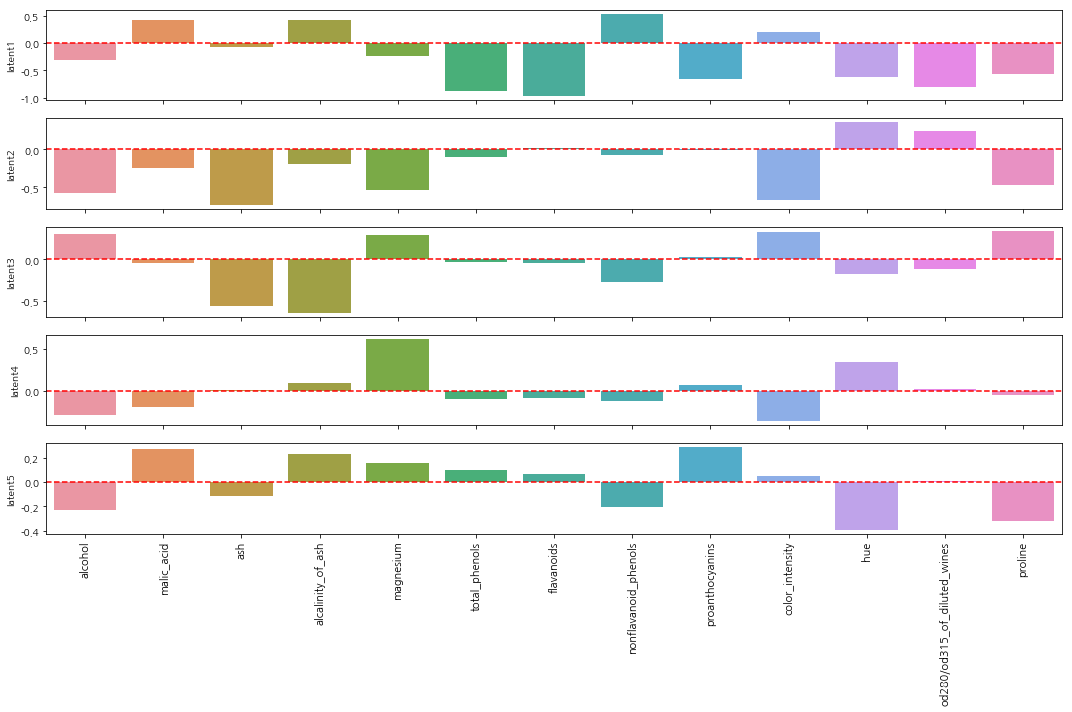

In [6]:
fig, ax = plt.subplots(fa_rs.shape[1], 1, figsize=(15, 10))

for i, idx in enumerate(max_var.index):
    sns.barplot(x=max_var.columns, y=max_var.iloc[i], ax=ax[i])
    ax[i].axhline(y=0, color='r', linestyle='--')
    if i != 4:
        ax[i].set_xticklabels([])
    else:
        ax[i].set_xticklabels(list(max_var.columns), rotation=90, fontsize=11)
plt.tight_layout()
plt.show()

## 독립성분 분석

ICA(Independent Component Analysis)는 다변량 신호를 통계적으로 최대 독립적인 성분으로 분해해 원래의 근원 신호를 복원하려는 기법  
주된 목적은 차원 축소가 아니라 중첩·혼합된 신호의 분리이며, 신호 잡음이나 회전 등을 제거해 “각 신호가 따로따로” 존재하도록 하는 것 ICA 모델에는 잡음항이 포함되어있지 않기 때문에 모델의 정확도를 위해 백색화가 필요

- 백색화란 무엇인가?
  백색화(whitening, sphering)는 입력 벡터를 **공분산 행렬이 단위 행렬(𝐈)**이 되도록 선형 변환하는 작업 
  - 모든 변수가 서로 독립(무상관) 이고
  - 각 변수가 분산 1을 갖는다.
  - 백색화 후의 데이터는 통계적으로 “백색 잡음(white noise)”와 같은 특성을 띈다.

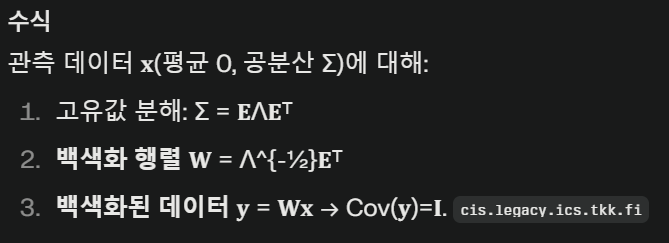

- 왜 필요한가?
  - ICA 알고리즘 단순화·수렴 속도 향상
    백색화를 하면 ICA가 추정할 매개변수가 회전(정직교 행렬)으로만 제한되어 문제 차원이 줄어든다.
  - 잡음 감소 및 차원 감소 효과
    고유값이 작은 차원을 잘라내면 노이즈가 줄고 과적합을 방지한다.
  - 스케일·상관 제거로 수치 안정성 개선
    분산·단위가 다른 변수 간 계산 편향을 없앤다.
  
-  알고리즘: Infomax, FastICA, JADE 등

| 독립 성분          | 주요 기여 변수 (절댓값 기준 Top‑2)                                                               | 방향 및 설명                                                                                                       |
| -------------- | ------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **ind\_comp1** | **magnesium (–0.0703)**<br>**nonflavanoid\_phenols (0.0393)**                         | 마그네슘이 음수 방향, 비플라보노이드 페놀이 양수 방향으로 가장 크게 기여. <br>→ 제1성분은 **마그네슘 함량** 및 **비플라보노이드 페놀 특성**을 중심으로 한 화학적 특성 축       |
| **ind\_comp2** | **malic\_acid (–0.0515)**<br>**proanthocyanins (–0.0390)**<br>또는 hue (0.0366)\*\*     | 말산 및 프로안토시아닌이 음수 방향으로 강하게 기여하고, hue가 양수 방향으로 기여. <br>→ 제2성분은 **말산·프로안토시아닌**량 증가와 **색상(hue)** 변화가 결합된 복합적 특성 축 |
| **ind\_comp3** | **flavanoids (0.0175)**<br>**total\_phenols (0.0162)**<br>또는 od280/od315 (0.0167)\*\* | 페놀 계열 변수들과 OD 비율이 모두 양의 방향으로 작게 기여. <br>→ 제3성분은 **페놀 성분 강도 및 희석 와인 OD 비율**과 관련된 특성 중심                         |
| **ind\_comp4** | **color\_intensity (0.0312)**<br>**alcohol (0.0287)**<br>또는 proline (0.0212)\*\*      | 색도·알코올·프롤린이 양수 방향으로 기여. <br>→ 제4성분은 **색 농도 증가**, **알코올 함량 증가**, **프롤린** 증가가 함께 나타나는 축                         |
| **ind\_comp5** | **ash (–0.0471)**<br>**alcalinity\_of\_ash (–0.0399)**                                | 회분과 회분의 알칼리도가 음수 방향으로 가장 크게 기여. <br>→ 제5성분은 **무기물 조성** (회분 및 알칼리도) 중심의 변화 축                                   |

<활용방안>
- 시각화: 샘플별 ind_comp1·2·3을 3D 스캐터로 플롯해 군집(품종) 분리도 확인
- 모델 입력: 분류·회귀 모델의 피처로 사용 시 노이즈 제거·차원 축소 효과
- 화학적 해석: 각 독립성분이 대표하는 와인 특성(미네랄, 페놀, 색도 등)을 중심으로 품질·품종 차이 분석

In [7]:
#ICA 적합
from sklearn.decomposition import FastICA

ica = FastICA(n_components=5, algorithm='parallel', whiten=True, fun='logcosh')
I_rs = ica.fit_transform(s_train_X)

#독립성분을 얻기 위해 데이터에 적용할 선형 연산자
ind_comp = pd.DataFrame(ica.components_, index=['ind_comp'+str(i) for i in range(1, I_rs.shape[1]+1)], columns=X.columns)
display(ind_comp)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
ind_comp1,0.027114,0.016642,-0.003013,-0.017397,0.010742,0.003251,0.000725,-0.011046,0.002477,0.030274,-0.023184,-0.007601,0.019131
ind_comp2,-0.006557,0.010630,-0.003179,0.006985,0.003818,-0.017930,-0.019096,0.004897,-0.011083,0.005708,-0.015039,-0.017834,-0.010620
ind_comp3,-0.011870,0.052115,-0.020078,0.008229,-0.015675,0.013673,0.013404,-0.029831,0.030735,-0.003087,-0.033637,0.016988,-0.023752
ind_comp4,0.023328,0.008607,0.006867,-0.006992,-0.072930,0.015394,0.012610,0.035672,-0.011313,0.009743,-0.002587,0.012214,0.004001
ind_comp5,-0.000163,0.011649,0.048367,0.043071,0.011745,0.012322,0.008061,0.012429,0.012407,0.000277,0.001187,0.004865,-0.002360


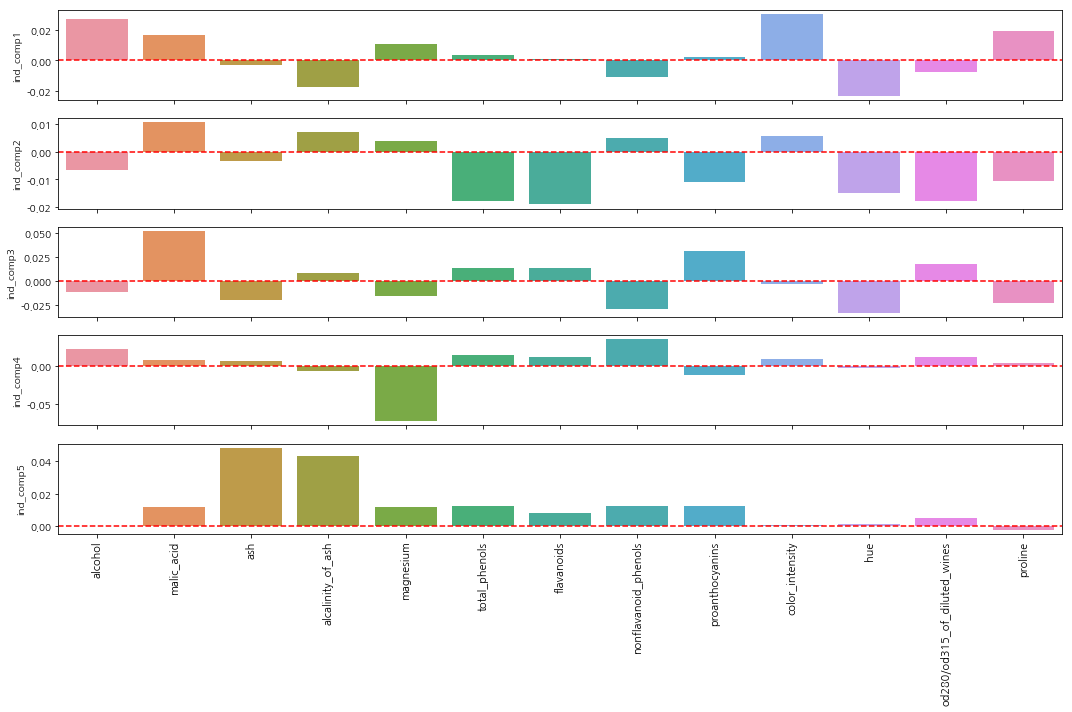

In [8]:
fig, ax = plt.subplots(I_rs.shape[1], 1, figsize=(15, 10))

for i, idx in enumerate(ind_comp.index):
    sns.barplot(x=ind_comp.columns, y=ind_comp.iloc[i], ax=ax[i])
    ax[i].axhline(y=0, color='r', linestyle='--')
    if i != 4:
        ax[i].set_xticklabels([])
    else:
        ax[i].set_xticklabels(list(ind_comp.columns), rotation=90, fontsize=11)
plt.tight_layout()
plt.show()

## 음수 미포함 행렬 분해

음수 미포함 행렬 분해(NMF)는 데이터와 구성요소가 음수가 아니라는 가정 하에 진행하는 분해방법  
원본 데이터 X를 음수를 포함하지 않는 두 개의 행렬 W와 H로 분해 시, 데이터 X와 행렬 WH 사이의 거리인 d를 최적화하면서 진행  
거리 d는 주로 squared Frobenius norm으로 계산  
PCA와 달리 벡터표현은 구성요소를 제거하지 않고 겹쳐서 덧셈 방식으로 얻으며, 이미지와 텍스트를 표현하는데 효율적임  
- 사용분야: 차원축소, 소스분리, 주제 추출

| 컴포넌트           | 주요 기여 변수 (가중치 상위 2‑3개)                                                                                 | 해석 요약                                                             |
| -------------- | ------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------- |
| **nmf\_comp1** | **proline (0.6049)**<br>alcohol (0.4435), ash (0.3976)                                                 | proline이 가장 크게 기여, 알코올과 회분(ash)도 높음 → 주로 **고프롤린·고알코올·고회분 특성**     |
| **nmf\_comp2** | **color\_intensity (0.5559)**<br>nonflavanoid\_phenols (0.4110), alcohol (0.4186)                      | 색 농도, 비플라보노이드 페놀, 알코올 중심 → **색 강도와 관련된 phenol/알코올 축**             |
| **nmf\_comp3** | **alcalinity\_of\_ash (1.1230)**<br>ash (0.9362), hue (0.9943)                                         | 회분 알칼리도와 ash, hue가 매우 강하게 기여 → **무기물‐염기성 및 색상 특성 축**              |
| **nmf\_comp4** | **alcalinity\_of\_ash (0.4826)**<br>malic\_acid (0.4099), ash (0.4064)                                 | 말산과 ash, ash 알칼리도 중심 → **산성(말산)·무기물 조성 특성 결합 기조**                 |
| **nmf\_comp5** | **total\_phenols (0.7587)**<br>flavanoids (0.6573), nonflavanoid\_phenols (0.6396), od280/315 (0.8826) | 페놀 계열 변수들이 모두 높음 → **총 페놀·플라바노이드·OD 비율 중심의 phenolic intensity 축** |

<활용방안>
- 클러스터링 및 시각화: nmf_comp1·2·3 등 성분 점수를 이용해 품종 간 군집 분리
- 모델 입력: 분류·회귀 시 NMF 성분을 사용해 변수 개수 축소 및 노이즈 완화
- 화학적 특성 분석: 각 성분 축별로 와인 품질 또는 품종 특성(미네랄, 색도, 페놀 등) 비교

In [9]:
# 음수가 포함되지 않아야 하므로 sc 대신 minmax scaler 사용
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
m_train_X = pd.DataFrame(mm.fit_transform(train_X), columns=X.columns)

#NMF
from sklearn.decomposition import NMF

nmf = NMF(n_components=5, init='random', max_iter=2000)
m_rs = nmf.fit_transform(m_train_X)

# Factorization matrix
nmf_comp = pd.DataFrame(nmf.components_, index=['nmf_comp'+str(i) for i in range(1, m_rs.shape[1]+1)], columns=X.columns)
display(nmf_comp)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
nmf_comp1,0.000000,0.000000,0.327462,0.453902,0.384785,0.073185,0.065851,0.000000,0.194700,0.000000,0.188701,0.098989,0.000000
nmf_comp2,0.169592,0.140293,0.100091,0.037413,0.000000,0.427573,0.565134,0.000000,0.305242,0.000000,0.274890,0.589196,0.144580
nmf_comp3,0.236958,0.570246,0.270114,0.345861,0.083771,0.082103,0.010607,0.296379,0.114789,0.272115,0.000000,0.077875,0.000000
nmf_comp4,0.829039,0.000000,0.374675,0.000000,0.458333,0.272483,0.247942,0.001116,0.142423,0.649308,0.000000,0.000000,0.886718
nmf_comp5,0.101247,0.000000,0.376068,0.408987,0.000000,0.048526,0.000000,1.052544,0.016500,0.011250,0.382289,0.099684,0.000000


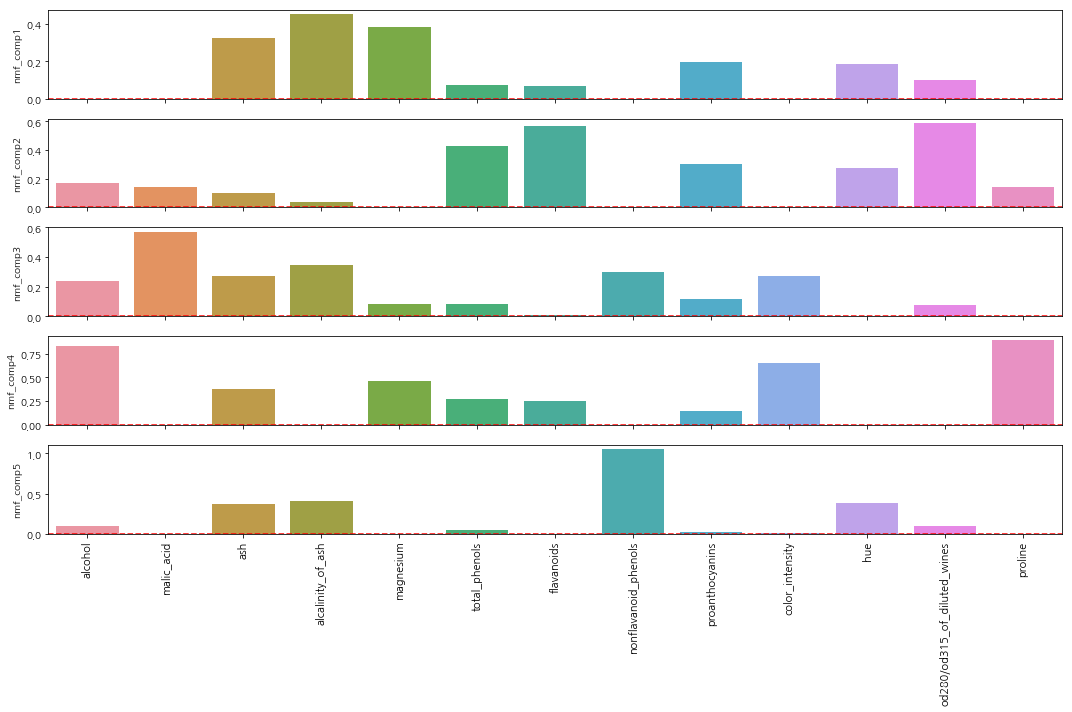

In [10]:
fig, ax = plt.subplots(m_rs.shape[1], 1, figsize=(15, 10))

for i, idx in enumerate(nmf_comp.index):
    sns.barplot(x=nmf_comp.columns, y=nmf_comp.iloc[i], ax=ax[i])
    ax[i].axhline(y=0, color='r', linestyle='--')
    if i != 4:
        ax[i].set_xticklabels([])
    else:
        ax[i].set_xticklabels(list(nmf_comp.columns), rotation=90, fontsize=11)
plt.tight_layout()
plt.show()

## 다차원척도법

다차원 척도법(MDS)은 고차원 데이터 간의 유사도(또는 거리) 정보를 차원 공간에 임베딩하여 시각화하거나 구조를 탐색하는 기법이다.  

### 1. 개념 및 절차  
MDS는 객체들 간의 **유사도(similarity)** 또는 **비유사도(dissimilarity, 거리)** 행렬을 입력으로 받아, 각 객체를 저차원(보통 2D 또는 3D) 좌표로 배치한다.  
- **입력**: $n$개 객체 간 거리 행렬 $\{d_{ij}\}$ 
- **목표**: 저차원 공간 좌표 $\{\mathbf{x}_i\in\mathbb R^p\}$를 찾아,  
  $
    \|\,\mathbf{x}_i - \mathbf{x}_j\|\approx d_{ij}
  $ 가 되도록 하는 것  

주요 단계  
1. 유사도/거리 계산: 원 데이터로부터 $d_{ij}$ 산출  
2. 중심화 및 그래디언트 반복: 스트레스 함수(stress) 최소화
   $$
     \text{Stress}=\sqrt{\frac{\sum_{i<j}\bigl(\|x_i-x_j\|-d_{ij}\bigr)^2}{\sum_{i<j}d_{ij}^2}}
   $$   
3. 저차원 좌표 얻기: 수렴 시점의 $\{\mathbf{x}_i\}$

### 2. 특징  
- **비모수적(Non-metric) MDS**: 순위 기반 거리(순서 정보)만 유지  
- **모수적(Metric) MDS**: 실제 거리값을 보존  
- **차원 결정**: 최적 차원 $p$는 스트레스 값 추세로 선택  
- **시각화**: 데이터 구조(클러스터, 연속적 경향 등) 탐색에 유용  

### 3. 장점  
- 복잡한 고차원 거리 구조를 직관적 시각화  
- 비모수적 MDS로 순위 정보만으로도 적용 가능하여, 비선형 관계 포착  
- PCA가 거리가 아닌 분산을 기준으로 하는 데 반해, **거리 자체**를 보존하려 함  
- 다양한 거리 함수(유클리드, 맨해튼, 코사인 등) 사용 가능  

### 4. 단점  
- **계산 비용**이 $O(n^2)$ 거리 계산 + 반복적 최적화로 커 대규모 데이터에 부적합  
- **지역 최적해** 문제: 초기 좌표에 따라 다른 결과  
- 스트레스 최소화가 불안정하여 해석이 모호할 수 있음  
- 고차원 구조를 저차원에 압축하면서 **정보 손실** 발생  
- 차원 수 $p$ 선택이 명확치 않음(경험적 판단 필요)  

**요약**:  
MDS는 객체 간 거리 정보를 저차원에 재현해 데이터 구조를 시각화·탐색하는 강력한 기법이지만, 계산량·최적화 불안정성·정보 손실 등의 한계가 있다.

| 범위                  | 해석 수준        | 설명                              |
| ------------------- | ------------ | ------------------------------- |
| `0.000 ≤ s ≤ 0.025` | Excellent    | 거의 왜곡 없이, 거리 보존 수준 매우 양호        |
| `0.025 < s ≤ 0.050` | Good         | 아주 작은 왜곡만 있으며, 거리 관계 대부분 유지     |
| `0.050 < s ≤ 0.100` | Fair         | 중간 정도의 왜곡 있으나, 전체 구조 파악에는 무리 없음 |
| `0.100 < s ≤ 0.200` | Poor         | 왜곡이 상당하며, 해석 시 주의 필요            |
| `s > 0.200`         | Unacceptable | 왜곡이 심각하여 2\~3차원으로 저차원화하기 부적합    |



차원수가 2일 때, stress는 0.237
차원수가 3일 때, stress는 0.146
차원수가 4일 때, stress는 0.102
차원수가 5일 때, stress는 0.072
차원수가 6일 때, stress는 0.053
차원수가 7일 때, stress는 0.038
차원수가 8일 때, stress는 0.029
차원수가 9일 때, stress는 0.022


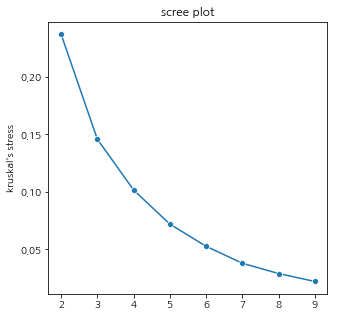

raw stress: 1195.61105100725(~1195.1708851248868)
krusckal stress: 0.07210603967010026


In [11]:
#이전의 sc 스케일링 데이터 사용
# 데이터 간 거리계산 후 거리 행렬 구성
from sklearn.metrics import pairwise_distances
dist = pairwise_distances(s_train_X) #유클리디안 거리

#최적의 차원수 찾기
slist = []
from sklearn.manifold import MDS

for i in range(2, 10): #2~9차원
    mds = MDS(n_components=i, metric=True, random_state=0)
    mds.fit(s_train_X)
    sk_stress = mds.stress_ # 0.5~np.sum((dist-reduced_d)**2)
    kr_stress = np.sqrt(sk_stress / (0.5 * np.sum(dist**2))) #Kruskal’s Stress-1
    slist.append(kr_stress)
    print(f"차원수가 {i}일 때, stress는 {kr_stress:.3f}")
    
#Scree plot으로 시각화 → stress가 급격히 줄어들다가 완만해지는 지점(엉보)을 찾아 적정 차원 결정
plt.figure(figsize=(5, 5))
sns.lineplot(x=np.arange(2, 10), y=slist, marker='o')
plt.title('scree plot')
plt.ylabel("kruskal's stress")
plt.show()

#msd 적합
mds = MDS(n_components=5, metric=True)
m_rs = pd.DataFrame(mds.fit_transform(s_train_X))
reduced_d = pairwise_distances(mds.embedding_)

raw_stress = 0.5*np.sum((dist-reduced_d)**2)
kr_stress = np.sqrt(mds.stress_/(0.5*np.sum(dist**2))) #np.sqrt(np.sum((dist-reduced_d)**2) / np.sum(dist**2))

print(f'raw stress: {mds.stress_}(~{0.5*np.sum((dist-reduced_d)**2)})')
print(f'krusckal stress: {kr_stress}')

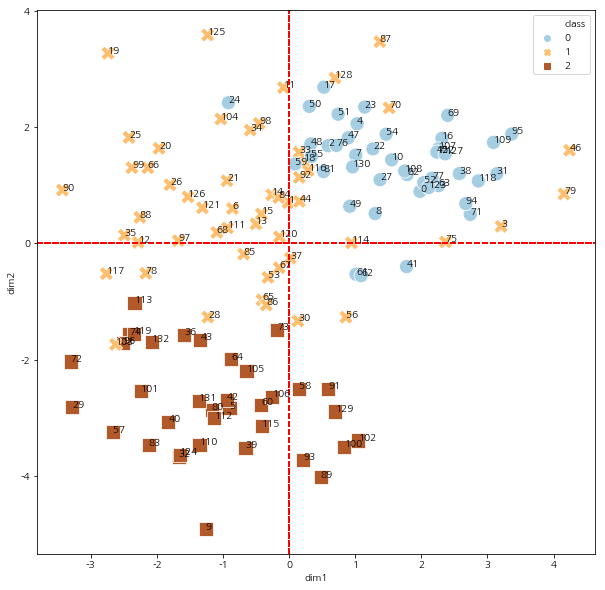

In [12]:
# 산점도로부터 wine 종류 간의 비유사도(거리) 확인 가능
reduced_dt = pd.DataFrame(np.c_[m_rs.values, train_Y], columns=['dim'+str(i) for i in range(1, 6)]+['class'])
reduced_dt['class'] = reduced_dt['class'].astype('int64')

plt.figure(figsize=(10, 10))
sns.scatterplot(x='dim1', y='dim2', data=reduced_dt, style='class', style_order=[0, 1, 2], hue='class', palette='Paired', s=200)
for i, name in enumerate(m_rs.index):
    plt.text(reduced_dt.loc[i, 'dim1'], reduced_dt.loc[i, 'dim2'], name)
    plt.axhline(0, 0, ls='--', color='r')
    plt.axvline(0, 0, ls='--', color='r')
plt.show()

In [13]:
#성능 비교
from sklearn.linear_model import LinearRegression

model_list = [pca, fa, ica, nmf, mds]
dt_title = ['original', 'pca', 'fa', 'ica', 'nmf', 'mds']
dt_list = [s_test_X]
dt_list2 = [s_train_X, rs, fa_rs, I_rs, m_rs, m_rs]

for title, model in zip(dt_title[1:], model_list):
    if title == 'nmf':
        test_X2 = mm.fit_transform(test_X) #이거는 앞에서 나누지 말것
    else:
        test_X2 = sc.transform(test_X)
    if title == 'mds':
        dt = pd.DataFrame(model.fit_transform(test_X2))
    else:
        dt = pd.DataFrame(model.transform(test_X2))
    dt_list.append(dt)
    
for title, train, test in zip(dt_title, dt_list2, dt_list):
    lr = LinearRegression().fit(train, train_Y)
    s1 = lr.score(train, train_Y)
    s2 = lr.score(test, test_Y)
    print(f"{title} train score: {s1:.3f} / test score: {s2:.3f}") #nmf, MDS는 transform 없어서 합친다음 분할 필요

original train score: 0.909 / test score: 0.845
pca train score: 0.829 / test score: 0.818
fa train score: 0.863 / test score: 0.799
ica train score: 0.829 / test score: 0.818
nmf train score: 0.797 / test score: 0.215
mds train score: 0.797 / test score: 0.221


# 10-2. 군집분석

## 군집분석(Clustering) 개념·장단점·종류

### 1. 개념  
군집분석은 관측치(데이터)를 **유성(거리·밀도·연관성 등)**에 따라 여러 집단(군집)으로 나누는 비지도 학습 기법입니다.  
- **목적**: 데이터 내부 구조 파악, 패턴 발견, 차원 축소 전 처리, 이상치 탐지 등  
- **핵심**: 같은 군집 내 데이터는 *서로 비슷*하고, 다른 군집 간 데이터는 *서로 다르다*.

### 2. 장점  
- 사전 레이블(정답) 없이 데이터 구조를 탐색할 수 있음.  
- 데이터 분포·패턴 파악, 고객 세분화, 이미지 분할, 문서 군집화 등에 활용.  
- 다양한 유사도 기준(유클리드 거리·코사인 유사도·밀도 등) 적용 가능

### 3. 단점  
- **군집 개수 결정**이 어려움(Elbow, 실루엣 기법 등 별도 평가 필요)
- 초기값·매개변수(**K**, **밀도 임계값**) 민감 → 결과 불안정
- 고차원·스케일 차 큰 데이터에 거리 왜곡 문제.  
- 대규모 데이터는 계산 비용이 큼(O(N²) 거리 계산).  
- 노이즈·이상치에 취약.

### 4. 주요 군집분석 기법  

| 분류         | 기법                    | 개념 요약                                                                                       | 특징 및 활용 예시                                                                                             |
|:------------|:-----------------------|:---------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------------------------------|
| **계층적**   | 병합적 계층적 군집화(Agglomerative)  | 모든 점을 개별 군집으로 시작하여, 유사도가 높은 두 군집을 반복적으로 합쳐 나가는 방식                   | -  덴드로그램 시각화로 전체 군집 구조 직관적 이해<br>-  소규모 데이터셋에 적합                                     |
|           -   | 분할적 계층적 군집화(Divisive)       | 전체 데이터를 하나의 군집으로 시작하여, 가장 이질적인 점들을 반복적으로 분할해 나가는 방식               | -  덴드로그램으로 분할 과정을 역으로 파악 가능<br>-  계산 비용 높아 소규모에 적합                                  |
| **비계층적** | K-평균 군집화            | K개의 중심(centroid)을 반복 갱신해 각 점을 가장 가까운 군집에 할당                                   | -  간단·빠름, 구형(cluster가 구 형태) 군집에 적합<br>-  군집 수 K 사전 지정 필요                                 |
|          -    | DBSCAN                  | ε-이웃 내 점의 밀도를 기준으로 핵심점·경계점·잡음을 구분해 군집 형성                                | -  임의 모양의 군집 탐지 가능-  노이즈(이상치) 자동 제거<br>-  ε, MinPts 설정 민감                             |
|           -   | Mean Shift              | 커널 밀도 추정으로 데이터의 밀집 영역(모드)으로 점들을 이동시켜 군집화                                | -  군집 수 미리 지정 불필요-  계산량 많아 중소규모 데이터에 적합                                              |
|            -  | Gaussian Mixture Model  | 여러 개의 가우시안 분포를 혼합해 데이터 분포를 추정하고, 각 점의 소속 확률로 군집화                    | -  확률적(soft) 할당-  군집 간 중첩 허용<br>-  EM 알고리즘 기반                                              |
|             - | Spectral Clustering     | 유사도 그래프의 라플라시안 행렬 고유벡터를 이용해 저차원으로 임베딩한 뒤 k-평균 등으로 군집화           | -  비구형·복잡 구조의 군집에 강함<br>-  그래프 이론 기반, 커널 선택 및 스케일링 민감                               |

각 기법의 선택은 데이터 특성(차원·크기·분포)과 목적(경계 선명도·잡음 여부)에 따라 달라집니다.

## 10-2-1. 계층적 군집분석

덴드로그램을 통해 서로 다른 수의 클러스터를 지정하는 과정을 시각화 할 수 있음. 특이점이나 비정상적인 그룹을 발견하기 쉬우며,  
해석이 용이함. 연산량이 많아 대규모 데이터에는 적용할 수 없음.  
합병형 알고리즘은 단일 레코드로 구성된 클러스터에서 시작하여 유사한 클러스터들을 반복적으로 병합하며 더 큰 클러스터를 생성

<클러스터 합병방법: 정의된 거리가 가장 짧은 두 클러스터를 합침>

| 병합 방법            | 정의                                                           | 특징                                                         |
|---------------------|--------------------------------------------------------------|------------------------------------------------------------|
| **단일 연결법 (Single linkage)** | 두 클러스터 간 모든 쌍의 점들 중 **가장 가까운 점** 간 거리를 클러스터 간 거리로 정의 | - 민감하게 “체인(chaining)” 현상 발생- 잡음에 취약, 길게 연결되는 구조 생성 |
| **완전 연결법 (Complete linkage)** | 두 클러스터 간 모든 쌍의 점들 중 **가장 먼 점** 간 거리를 클러스터 간 거리로 정의  | - 콤팩트한(밀집된) 클러스터 생성- 이상치에 민감하지 않으나, 구형 클러스터에 적합 |
| **평균 연결법 (Average linkage)** | 두 클러스터 간 **모든 점 쌍 거리의 평균**을 클러스터 간 거리로 정의               | - 단일·완전 연결법의 중간 형태- 균형 잡힌 클러스터 크기 유지                   |
| **최소분산법 (Ward’s method)**    | 합병 후 클러스터의 **분산 증가량(오차제곱합 증가)**이 최소가 되도록 클러스터를 합병 | - 분산 기반 최적화로, 구형·동질적 클러스터 생성- 계산 비용이 상대적으로 높음      |

- **병합 절차**: 초기에는 각 관측치를 하나의 클러스터로 두고, 반복적으로 위 정의에 따라 두 클러스터를 합쳐 나감.
- **선택 포인트**:  
  - 단일 연결법은 긴 사슬 모양(clusters chaining) 구조를,  
  - 완전 연결법과 Ward 방법은 구형·조밀한(clique-like) 구조를 잘 찾아냄.  
  - 평균 연결법은 이 둘의 타협안이라 볼 수 있음.


In [14]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

X = load_iris().data
Y = load_iris().target

col_list = [i.replace(" (cm)", '') for i in load_iris().feature_names]

#데이터표준화
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
dt = pd.DataFrame(sc.fit_transform(X), columns=col_list)

#군집화 매트릭스
z = linkage(dt, method='complete') #single, complete, average, weighted, centroid, median, ward
display(z[:3, :].round()) #0~1열: 인덱스, 2열: 0~1열 인덱스 쌍의 거리, 3열: 클러스터 내 관찰값 개수

array([[101., 142.,   0.,   2.],
       [  7.,  39.,   0.,   2.],
       [ 10.,  48.,   0.,   2.]])

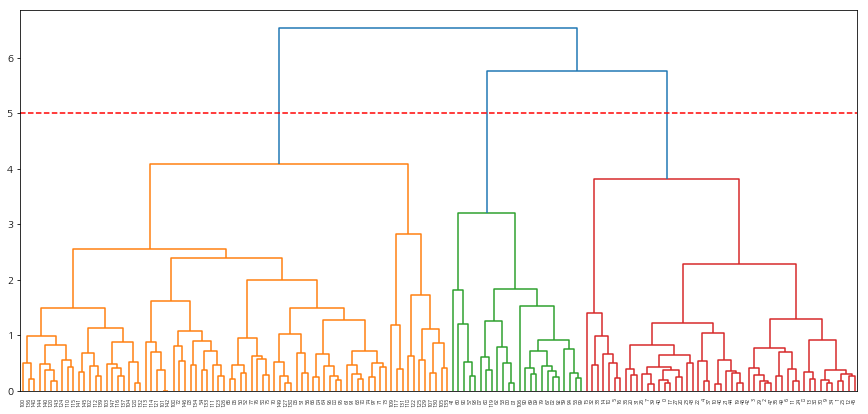

In [15]:
#군집화 결과 시각화
dist_set = 5

plt.figure(figsize=(15, 7))
dendrogram(z, labels=dt.index, color_threshold=dist_set) #해당 거리값 기준 색상이 다른 군집들로 나눠줌
plt.xticks(rotation=90)
plt.axhline(y=dist_set, ls='--', color='r')
plt.show()

지정한 거리 5 기준으로 4개의 클러스터로 나뉨을 알 수 있다.

In [16]:
#지정한 군집개수 기반으로 각 데이터 군집 변환
n_cluster = 4
H_rs = cut_tree(z, n_cluster).flatten()
print(Counter(H_rs))

Counter({2: 66, 0: 49, 1: 24, 3: 11})


In [17]:
#타당성 평가: 클러스터링한 군집번호와 타겟의 군집번호가 반드시 일치할 필요는 없으며, 유사한 데이터 간 군집화만 잘 되어있으면 됨
from sklearn.metrics import silhouette_score, completeness_score

print(f"실루엣 계수: {silhouette_score(dt, H_rs)}")
print(f"completeness_score: {completeness_score(Y, H_rs)}")

실루엣 계수: 0.4106070581516945
completeness_score: 0.5974736953718882


| 척도 이름             | 값이 클수록 좋은가? | 주요 특징                   |
| ----------------- | ----------- | ----------------------- |
| Silhouette 계수     | ✔️ Yes      | +1에 가까울수록 좋음, 직관적 해석 가능 |
| Calinski-Harabasz | ✔️ Yes      | 분산 기반, 클수록 좋음           |
| Davies-Bouldin    | ❌ No        | 작을수록 좋음, 클수록 군집 간 중복 많음 |
| Dunn Index        | ✔️ Yes      | 군집 간 분리, 내부 응집도 동시에 고려  |


📊 1. Silhouette 계수

| 항목     | 내용                                                                     |
| ------ | ---------------------------------------------------------------------- |
| 정의     | 한 클러스터 내 평균 거리와 가장 가까운 다른 클러스터와의 평균 거리 차이를, 두 값의 최대값으로 나눈 비율           |
| 값의 범위  | –1.0 \~ +1.0                                                           |
| 해석 기준  | 0.7 \~ +1.0: 매우 우수<br>0.5 \~ 0.7: 양호<br>0.25 \~ 0.5: 보통<br>< 0.25: 부적절 |
| 측정값 예시 | 0.6849                                                                 |

📊 2. Completeness Score

| 항목     | 내용                                                                                                |
| ------ | ------------------------------------------------------------------------------------------------- |
| 정의     | 동일한 정답 레이블을 가진 샘플들이 **동일한 클러스터에 배정**되었는지를 측정하는 지표                                                 |
| 값의 범위  | 0.0 \~ 1.0                                                                                        |
| 해석 기준  | 1.0에 가까울수록 좋음 (완전하게 하나의 군집에 모여 있을수록 높음)                                                           |
| 특징     | `homogeneity_score`와 함께 자주 사용됨. <br> `v_measure_score = harmonic_mean(homogeneity, completeness)` |
| 측정값 예시 | 예: 0.73                                                                                           |


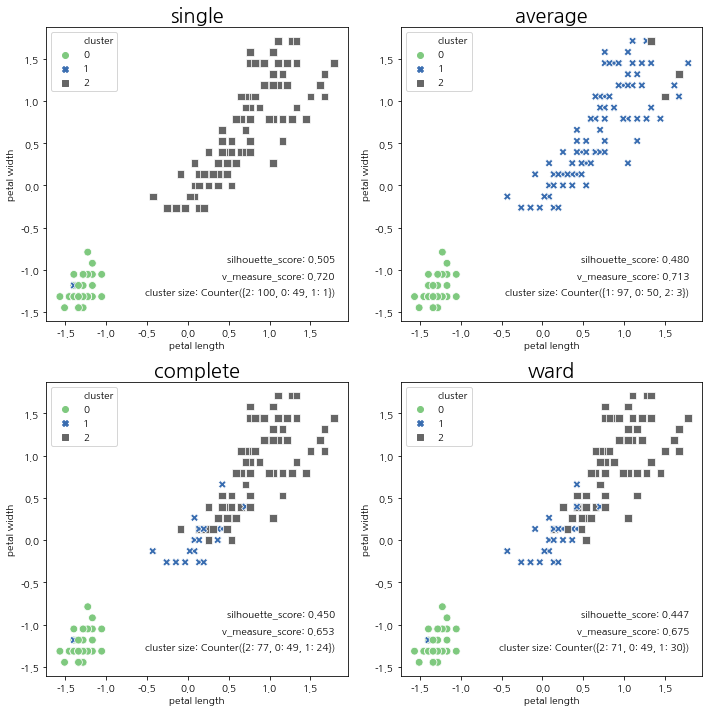

In [18]:
#비유사도 측정지표별 군집결과 비교
from sklearn.metrics import silhouette_score, v_measure_score

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

methods = ['single', 'average', 'complete', 'ward']

for ax, me in zip(axes.ravel(), methods):
    z = linkage(dt, method=me)
    cluster = pd.DataFrame({'cluster': cut_tree(z, 3).flatten()})
    ddf = pd.merge(dt, cluster, left_index=True, right_index=True) #클러스터링된 클래스와 합침
    sns.scatterplot(x='petal length', y = 'petal width', data=ddf, hue='cluster', style='cluster', s=60, ax=ax, palette='Accent')
    
    s1 = silhouette_score(dt, ddf['cluster']) #실루엣 점수
    s2 = v_measure_score(Y, ddf['cluster']) #v_measure
    c_size = Counter(ddf['cluster'])
    
    ax.text(1.8, -0.9, f"silhouette_score: {s1:.3f}", horizontalalignment='right')
    ax.text(1.8, -1.1, f"v_measure_score: {s2:.3f}", horizontalalignment='right')
    ax.text(1.8, -1.3, f"cluster size: {c_size}", horizontalalignment='right')
    
    ax.set_title(me, fontsize=20)
plt.tight_layout()
plt.show()

score는 single이 가장 높으나, 3개 군집을 제대로 분류하지 못하였다.  
그래프 상으로는 complete나 ward가 적절하다고 판단

# 10-2-2. 비계층적 군집분석
## K-means clustering

사용자가 미리 정한 k값과 클러스터 평균의 초기값을 가지고 알고리즘을 시작하며, 다음의 과정을 반복  
1. 각 데이터를 거리가 가장 가까운 평균을 갖는 클러스터에 할당
2. 새로 할당된 데이터들로 새로운 클러스터 평균 계산
3. 각 데이터에 대한 클러스터 할당이 변하지 않을 때까지 반복, 수렴하면 종료

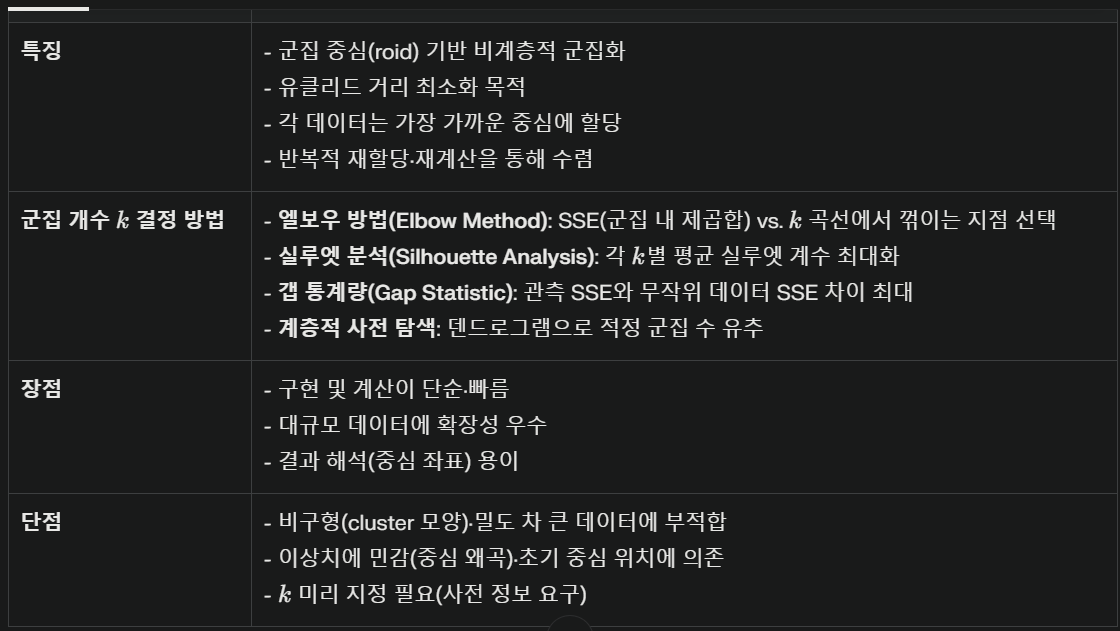


적정한 군집 개수 정하기:


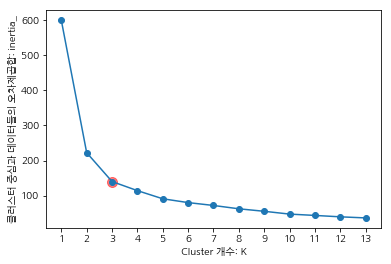

In [19]:
# K-means clustering
from sklearn.cluster import KMeans

# 데이터 불러오기 및 표준화는 이전 것 사용
# 적정한 군집 개수 정하기
print("적정한 군집 개수 정하기:")
I = [] # 오차제곱합
for k in range(1,14): #feature 개수
    kmeans=KMeans(n_clusters=k).fit(dt)
    I.append(kmeans.inertia_) # 오차제곱합
plt.plot(list(range(1,14)), I, marker="o")

n_cluster = 3
plt.scatter(n_cluster, I[n_cluster-1], color='red', alpha=0.5, s=100)
plt.xticks(list(range(1,14)), list(range(1,14)))
plt.xlabel("Cluster 개수: K")
plt.ylabel("클러스터 중심과 데이터들의 오차제곱합: inertia_")
plt.show()

In [20]:
# n_cluster로 정한 군집의 개수를 기반으로 각 데이터의 군집을 반환
model = KMeans(n_clusters=n_cluster, random_state=0)
distances = model.fit_transform(dt) # 해당 열 데이터의 각 cluster center와의 거리
kmeans_result = model.labels_ # 각 데이터의 군집 반환
print(kmeans_result)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [21]:
# 군집 정보 확인
print("클러스터 구성: ", Counter(model.labels_))
centers = pd.DataFrame(model.cluster_centers_, columns=dt.columns, index=["cluster"+str(i) for i in range(n_cluster)])
print("클러스터 중심:")
display(centers)

클러스터 구성:  Counter({2: 53, 1: 50, 0: 47})
클러스터 중심:


,sepal length,sepal width,petal length,petal width
cluster0,1.135970,0.088422,0.996155,1.017526
cluster1,-1.014579,0.853263,-1.304987,-1.254893
cluster2,-0.050220,-0.883376,0.347738,0.281527


In [22]:
Y.shape

(150,)

In [23]:
#타당성 평가: 클러스터링한 군집번호와 타겟의 군집번호가 반드시 일치할 필요는 없으며, 유사한 데이터 간 군집화만 잘 되어있으면 됨
from sklearn.metrics import silhouette_score, completeness_score

print(f"실루엣 계수: {silhouette_score(dt, kmeans_result)}")
print(f"completeness_score: {completeness_score(Y, kmeans_result)}")

실루엣 계수: 0.45994823920518635
completeness_score: 0.6598476779627759


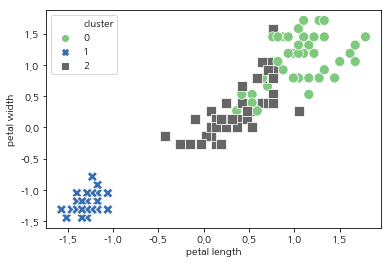

In [24]:
# 군집 결과 시각화
dt['cluster'] = kmeans_result
fig, ax = plt.subplots(1,1)
sns.scatterplot(x='petal length', y='petal width', data=dt, hue='cluster', style='cluster', s=100, ax=ax, palette='Accent')
plt.show()

## DBSCAN

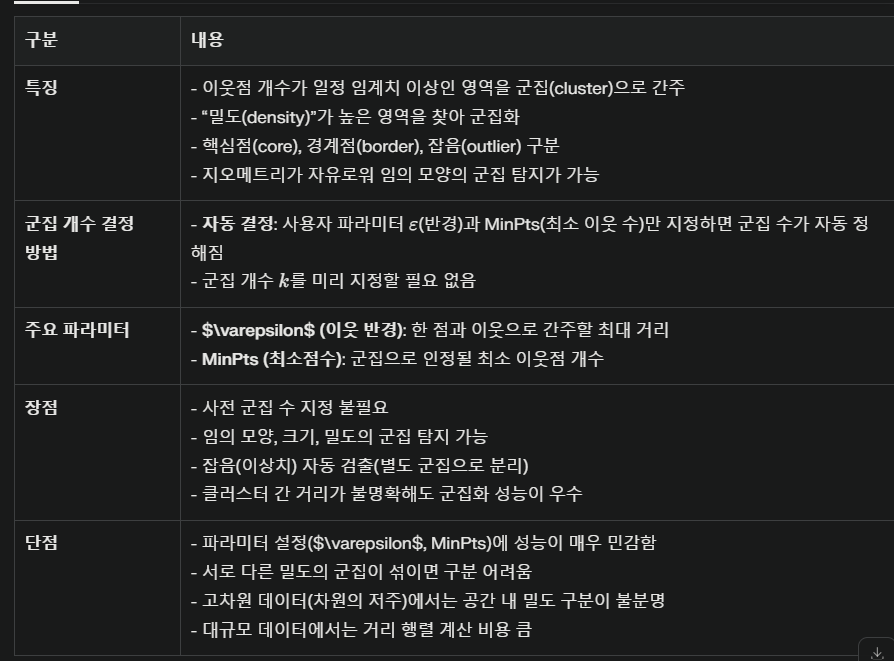

eps 0.5 잡음 수 : 39
eps 0.8 잡음 수 : 4
eps 1 잡음 수 : 3
eps 1.2 잡음 수 : 1


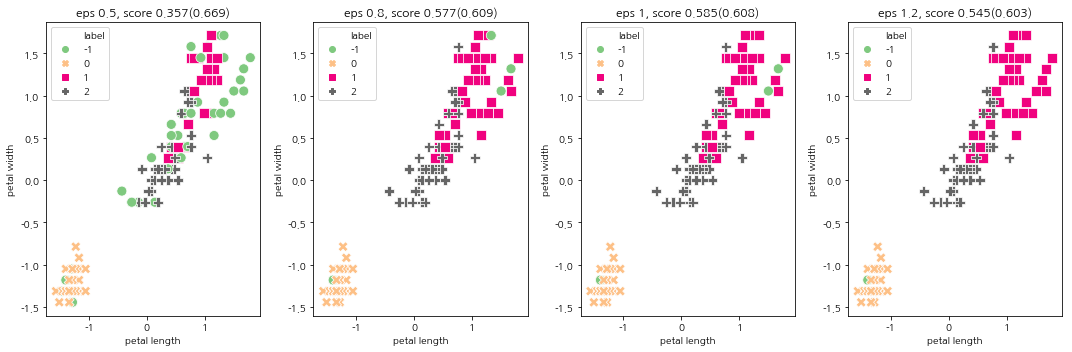

In [25]:
from sklearn.cluster import DBSCAN
#앞서 표준화한 데이터 사용
# dt.drop(columns='cluster', inplace=True)
# 적정한 eps 정하기 (min_samples는 10으로 고정함)
# eps를 증가시키면 하나의 클러스터에 더 많은 포인트가 포함된다. 
#이는 클러스터를 커지게 하지만 여러 클러스터를 하나로 합치게도 만든다. 
#min_samples는 클러스터의 최소 크기를 결정한다.print("적정한 eps 정하기:")
eps_list =[0.5, 0.8, 1, 1.2] # eps 후보군
fig, axes = plt.subplots(1,4, figsize = (15,5))
for ax, eps in zip(axes, eps_list):
    db = DBSCAN(eps=eps, min_samples = 5).fit(dt)
    temp_df = dt.copy()
    temp_df['label']=db.labels_ #예측결과
    sns.scatterplot(x='petal length', y='petal width', data=temp_df, hue='label', style='label', s=100, ax=ax, palette='Accent')
    e_idx = list(np.where(db.labels_ == -1)[0]) #잡음(레이블) 인덱스
    print(f"eps {eps} 잡음 수 : {len(e_idx)}")
    score = silhouette_score(dt[~dt.index.isin(e_idx)], db.labels_[db.labels_!=-1]) #잡음 제거한 score
    o_score = silhouette_score(dt, db.labels_) #원본데이터 스코어(잡음포함)
    ax.set_title(f"eps {eps}, score {o_score:.3f}({score:.3f})") #괄호는 잡음제거 스코어
plt.tight_layout()
plt.show()

eps 1의 score가 0.538로 가장 높다. 또한 -1 클러스터로 분류된 잡음의 수가 3개 정도로 적으므로 eps 1을 거리로 지정한다. 

In [26]:
# 확정한 eps를 기반으로 각 데이터의 군집을 반환
eps = 1
model = DBSCAN(eps=eps, min_samples = 10).fit(dt)
DB_result = model.labels_ # 각 데이터의 군집 반환
print(DB_result)

#여기서 잡음 제거
mask = list(np.where(DB_result != -1)[0]) #잡음(레이블) 인덱스를 뺀 인덱스
DB_result = DB_result[mask]
print(DB_result)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  2  2  2  1  2  2  2 -1  2  2  2  2  1  2  2  2  2  1  2
  2  2  2  1  1  1  2  2  2  2  2  2  2  1  1  2  2  2  2  2  2  2  2  2
  2  2  2  2  1  2  1  1  1  1  2  1  1  1  1  1  1  2  2  1  1 -1  1  2
  1  2  1  2  1  1  2  1  1  1  1 -1  1  2  2  1  1  1  2  1  1  1  2  1
  1  1  2  1  1  2]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 2 2 2 1 2 2 2 2 2 2 2 1 2 2 2 2 1 2 2 2 2 1
 1 1 2 2 2 2 2 2 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1 1 1
 2 2 1 1 1 2 1 2 1 2 1 1 2 1 1 1 1 1 2 2 1 1 1 2 1 1 1 2 1 1 1 2 1 1 2]


In [27]:
# 군집 정보 확인
print("클러스터 구성: ", Counter(DB_result)) # 노이즈 샘플은 제거
print("핵심 데이터 인덱스: ", model.core_sample_indices_)

클러스터 구성:  Counter({2: 52, 0: 49, 1: 45})
핵심 데이터 인덱스:  [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  34  35  36  37
  38  39  40  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  58  59  61  62  63  64  65  66  67  69  70  71  72  73  74  75  76  77
  78  79  80  81  82  83  84  86  88  89  90  91  92  94  95  96  97  98
  99 100 101 102 103 104 107 110 111 112 113 115 116 120 121 123 124 125
 126 127 128 129 130 132 133 134 136 137 138 139 140 141 142 143 144 145
 146 147 148 149]


In [28]:
#타당성 평가: 클러스터링한 군집번호와 타겟의 군집번호가 반드시 일치할 필요는 없으며, 유사한 데이터 간 군집화만 잘 되어있으면 됨
from sklearn.metrics import silhouette_score, completeness_score

print(f"실루엣 계수: {silhouette_score(dt.iloc[mask], DB_result)}")
print(f"completeness_score: {completeness_score(Y[mask], DB_result)}")

실루엣 계수: 0.6103932547022275
completeness_score: 0.6561279634422802


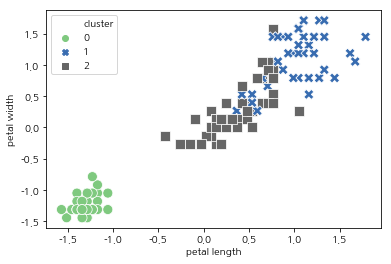

In [29]:
# 군집 결과 시각화
tmp = dt.iloc[mask]
tmp['cluster'] = DB_result
fig, ax = plt.subplots(1,1)
sns.scatterplot(x='petal length', y='petal width', data=tmp, hue='cluster', style='cluster', s=100, ax=ax, palette='Accent')
plt.show()

## 혼합 군집분포
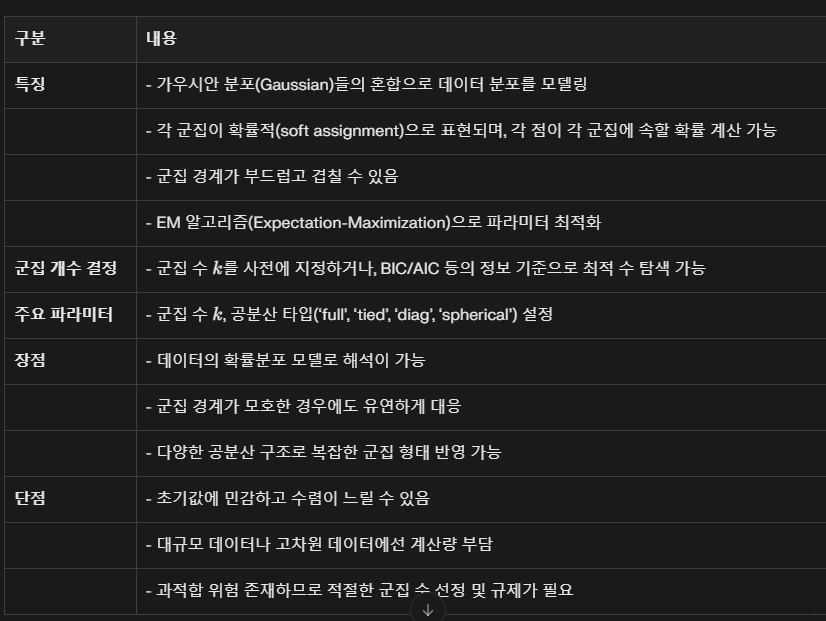

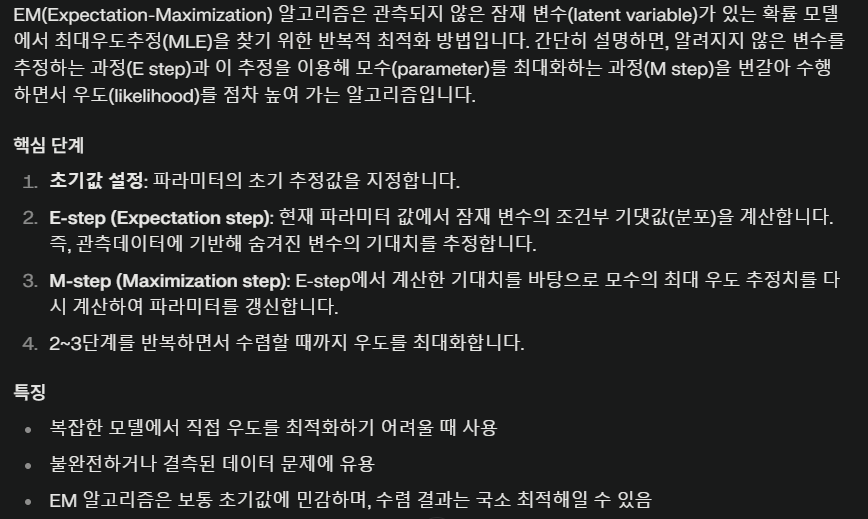

적정한 분포 개수 정하기:


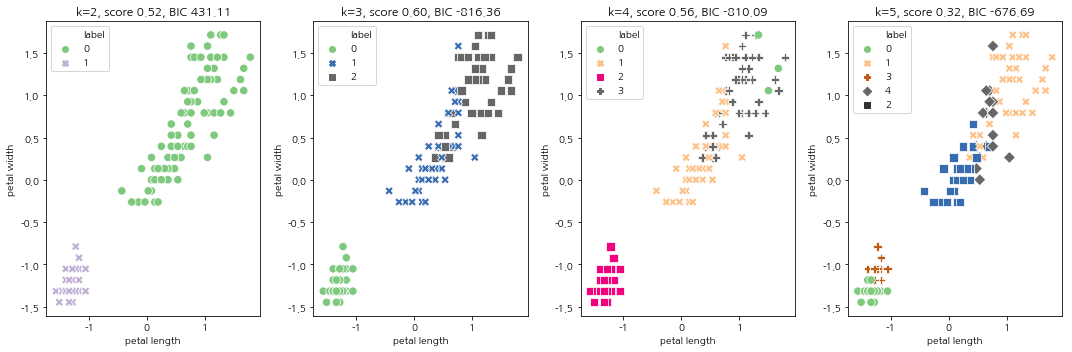

In [30]:
from sklearn.mixture import GaussianMixture

#앞서 표준화한 데이터 사용
# dt.drop(columns='cluster', inplace=True)

# 적정한 분포 개수 정하기 (=군집 개수 정하기)
print("적정한 분포 개수 정하기:")
dist_list =[2,3,4,5] # 분포 개수 후보군
fig, axes = plt.subplots(1,4, figsize = (15,5))
for ax, k in zip(axes, dist_list):
    gm = GaussianMixture(n_components=k, covariance_type='full').fit(dt)
    # covariance_type: {'full', 'tied', 'diag', 'spherical'}
    temp_df = dt.copy()
    temp_df['label']= gm.predict(dt)
    sns.scatterplot(x='petal length', y='petal width', data=temp_df, hue='label', style='label', s=70, ax=ax, palette='Accent')
    aic, bic = gm.aic(dt), gm.bic(dt)
    score = silhouette_score(dt, temp_df['label'])
    ax.set_title("k={}, score {:.2f}, BIC {:.2f}".format(k, score, bic))
plt.tight_layout()
plt.show()

score가 높을수록, BIC가 낮을수록 모델 성능이 좋다. score와 BIC가 가장 높고, 낮은 모델은 k=2일 때인데,  
산점도를 보면 이진 분류이다. 적어도 3개의 군집으로 분류를 한다고 가정하고 그 다음으로 좋은 성능을 보이는 k=3를 선택한다.

In [31]:
# 확정한 k를 기반으로 각 데이터의 군집을 반환
k = 3
model = GaussianMixture(n_components=k).fit(dt)
labels = model.predict(dt)
GM_result = labels # 각 데이터의 군집 반환
print(GM_result)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 2 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


In [32]:
# 군집 정보 확인
print("클러스터 구성: ", Counter(labels))
print("distribution 별 feature 평균: \n {}\n {}".format(model.means_[0], model.means_[1]))
print("distribution 별 가중치: ", model.weights_)
print("모델의 로그가능도: {:.3f}".format(model.score(dt)))

클러스터 구성:  Counter({1: 53, 0: 50, 2: 47})
distribution 별 feature 평균: 
 [-1.01457897  0.85326268 -1.30498732 -1.25489349  1.        ]
 [-0.05021989 -0.88337647  0.34773781  0.2815273   2.        ]
distribution 별 가중치:  [0.33333333 0.35333333 0.31333333]
모델의 로그가능도: 3.757


In [33]:
#타당성 평가: 클러스터링한 군집번호와 타겟의 군집번호가 반드시 일치할 필요는 없으며, 유사한 데이터 간 군집화만 잘 되어있으면 됨
from sklearn.metrics import silhouette_score, completeness_score

print(f"실루엣 계수: {silhouette_score(dt, GM_result)}")
print(f"completeness_score: {completeness_score(Y, GM_result)}")

실루엣 계수: 0.596923627959763
completeness_score: 0.659847677962776


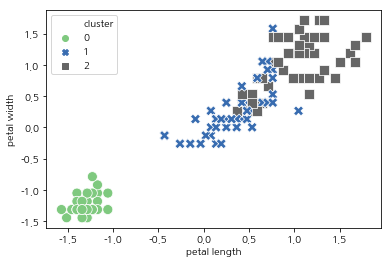

In [34]:
# 군집 결과 시각화
dt['cluster'] = GM_result
fig, ax = plt.subplots(1,1)
sns.scatterplot(x='petal length', y='petal width', data=dt, hue='cluster', style='cluster', s=100, ax=ax, palette='Accent')
plt.show()

## SOM: 미지원

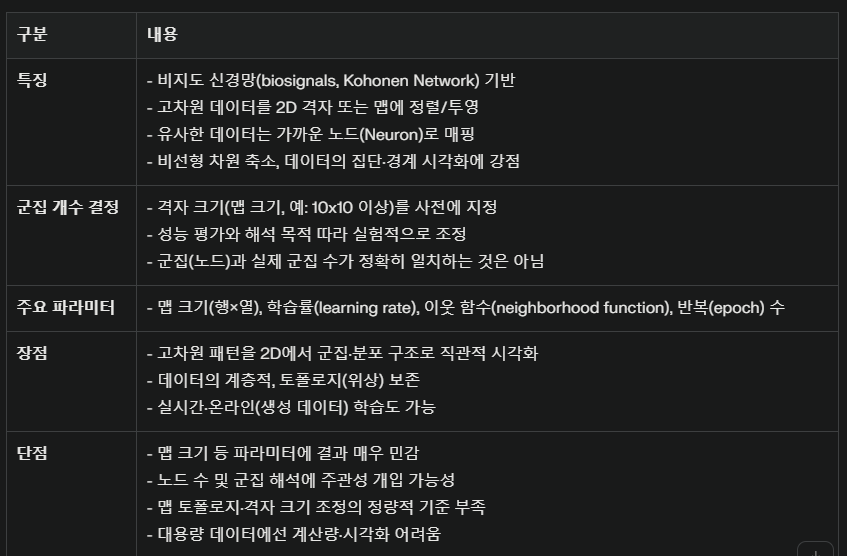

In [38]:
# !pip install sklearn-som

적정한 네트워크의 크기 정하기:


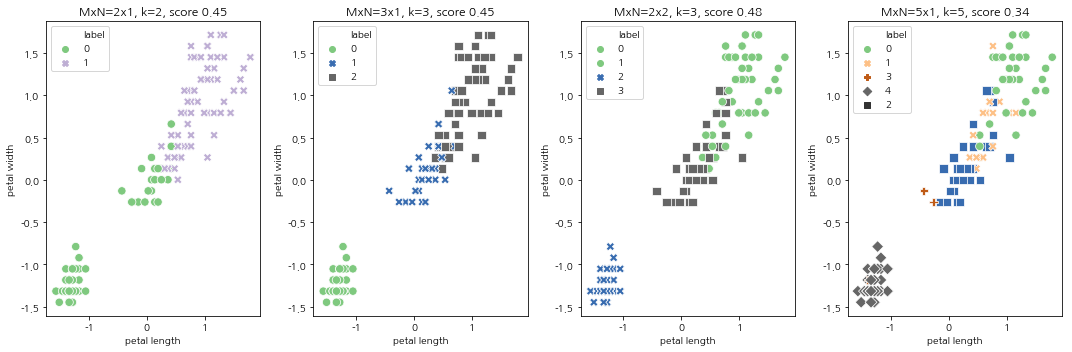

In [39]:
from sklearn_som.som import SOM
#앞서 표준화한 데이터 사용
# dt.drop(columns='cluster', inplace=True)

# 적정한 네트워크의 크기 정하기 (=군집 개수 정하기)
print("적정한 네트워크의 크기 정하기:")
mn_list =[(2,1), (3,1), (2,2), (5,1)] # 분포 개수 후보군
fig, axes = plt.subplots(1,4, figsize = (15,5))
for ax, (M, N) in zip(axes, mn_list):
    som = SOM(m=M, n=N, dim=dt.shape[1]) #dim은 입력 데이터의 feature의 개수
    som.fit(dt.values) #배열을 입력해야 함 (df형태는 안됨)
    labels = som.predict(dt.values)
    clusterNo = len(Counter(labels))
    temp_df = dt.copy()
    temp_df['label']= som.predict(dt.values)
    sns.scatterplot(x='petal length', y='petal width', data=temp_df, hue='label', style='label', s=70, ax=ax, palette='Accent')
    score = silhouette_score(dt, temp_df['label'])
    ax.set_title("MxN={}x{}, k={}, score {:.2f}".format(M,N,clusterNo,score))
plt.tight_layout()
plt.show()

3x1, 2x2이면서 k=3일 때 가장 좋은 성능

In [40]:
# 확정한 k를 기반으로 각 데이터의 군집을 반환
M, N = (3, 1)
model = SOM(m=M, n=N, dim=dt.shape[1])
model.fit(dt.values)
labels = model.predict(dt.values)
som_result = labels # 각 데이터의 군집 반환
print(som_result)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 2 1 2 1 2 1
 1 2 2 2 1 1 1 1 1 2 1 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [41]:
# 군집 정보 확인
SOMmap = model.transform(dt.values)
print("클러스터 구성: ", Counter(labels))
print("SOM map: \n", SOMmap[:5]) #앞 5개의 데이터 확인

클러스터 구성:  Counter({2: 66, 0: 50, 1: 34})
SOM map: 
 [[0.48462877 2.46833545 4.04232901]
 [1.46785222 2.43847293 3.92452444]
 [1.2030588  2.5826274  4.12263074]
 [1.42547698 2.58798336 4.09685484]
 [0.51849432 2.60393539 4.17352375]]


In [42]:
#타당성 평가: 클러스터링한 군집번호와 타겟의 군집번호가 반드시 일치할 필요는 없으며, 유사한 데이터 간 군집화만 잘 되어있으면 됨
from sklearn.metrics import silhouette_score, completeness_score

print(f"실루엣 계수: {silhouette_score(dt, som_result)}")
print(f"completeness_score: {completeness_score(Y, som_result)}")

실루엣 계수: 0.4219995365293202
completeness_score: 0.7684322991258717


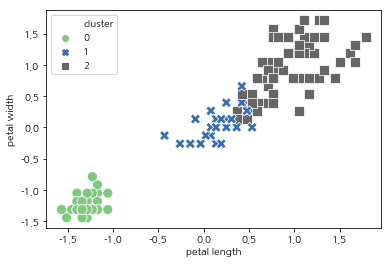

In [43]:
# 군집 결과 시각화
dt['cluster'] = som_result
fig, ax = plt.subplots(1,1)
sns.scatterplot(x='petal length', y='petal width', data=dt, hue='cluster', style='cluster', s=100, ax=ax, palette='Accent')
plt.show()

# 10-3. 연관규칙학습

## 1. 연관규칙학습 간략 설명

- **정의**: 거래 데이터(장바구니 데이터 등)에서 "A를 포함하면 B도 함께 등장한다"와 같은 항목들 간의 **빈번한 동시발생 패턴(association rule)**을 자동으로 찾아내는 데이터마이닝 기법
- **주요 목적**: 마켓바스켓 분석, 추천 시스템, 이탈 예측 등에서 변수간 관계성 탐색 및 인사이트 도출

## 2. 측정 척도(지표) 설명

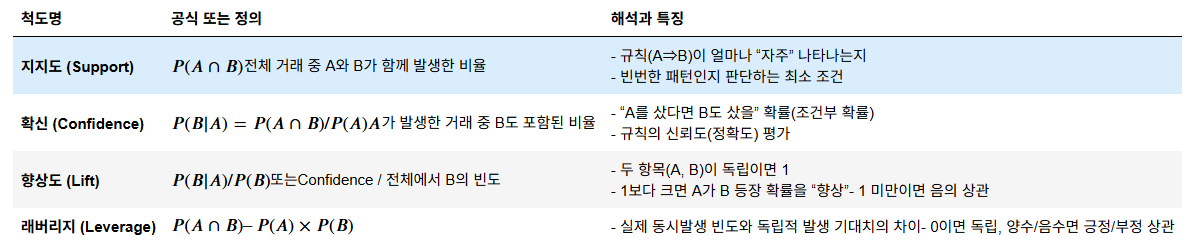

## 3. 연관규칙학습의 장단점

| 구분     | 내용                                                                                                             |
|:--------|:----------------------------------------------------------------------------------------------------------------|
| **장점**   | - 해석이 직관적(If-Then 규칙식)<br>- 복잡 데이터에서도 유의미 패턴 발굴<br>- 응용영역(리테일, 웹, 금융 등) 다양<br>- 전제 조건(분포, 선형성) 불필요 |
| **단점**   | - 대규모 데이터에서 조합 폭증(계산량 큼)- 임계값(최소 지지도, 확신도 등) 설정이 민감<br>- 규칙 중의미 없는 노이즈/우연적 관계도 많아 실무 해석 주의<br>- 희귀하지만 중요한 규칙(소비자 행동 변화 등) 탐지에 한계         |


**요약:**  
연관규칙학습은 데이터 내 항목 간 동시발생 패턴을 탐색하는 강력한 도구로, 지지도, 확신, 향상도, 래버리지 등의 지표로 규칙의 유의미성을 평가하며, 높은 해석성과 응용력을 가지나 계산량 및 실무적 한계도 있습니다.


In [44]:
# Transaction data(거래내역 데이터) 생성하기
from mlxtend.preprocessing import TransactionEncoder

dataset = [['Milk', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Dill', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Milk', 'Apple', 'Kidney Beans', 'Eggs'],
           ['Milk', 'Unicorn', 'Corn', 'Kidney Beans', 'Yogurt'],
           ['Corn', 'Onion', 'Onion', 'Kidney Beans', 'Ice cream', 'Eggs']]

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_).applymap(lambda x: 1 if x else 0)
display(df)
## 각 거래품목에 대한 거래 여부를 표시하는 데이터로 전처리 완료

,Apple,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Unicorn,Yogurt
0,0,0,0,1,0,1,1,1,1,0,1
1,0,0,1,1,0,1,0,1,1,0,1
2,1,0,0,1,0,1,1,0,0,0,0
3,0,1,0,0,0,1,1,0,0,1,1
4,0,1,0,1,1,1,0,0,1,0,0


In [45]:
# APRIORI 알고리즘으로 연관규칙학습

# 빈발항목집합 생성
from mlxtend.frequent_patterns import apriori
fset = apriori(df, min_support=0.6, use_colnames=True, verbose=0) 
print("빈발항목집합:\n", fset.sort_values(by='support', ascending=False))

빈발항목집합:
     support                     itemsets
1       1.0               (Kidney Beans)
0       0.8                       (Eggs)
5       0.8         (Eggs, Kidney Beans)
2       0.6                       (Milk)
3       0.6                      (Onion)
4       0.6                     (Yogurt)
6       0.6                (Eggs, Onion)
7       0.6         (Milk, Kidney Beans)
8       0.6        (Onion, Kidney Beans)
9       0.6       (Yogurt, Kidney Beans)
10      0.6  (Eggs, Onion, Kidney Beans)


In [46]:
# 연관규칙 생성
from mlxtend.frequent_patterns import association_rules
# metric = {'support', 'confidence', 'lift', 'leverage', 'conviction'}
# min_threshold = metric 파라미터 값의 최솟값 설정
rule = association_rules(fset, metric="confidence", min_threshold=0.7)
rule['len_ant'] = rule['antecedents'].apply(lambda x: len(x))
rule['len_con'] = rule['consequents'].apply(lambda x: len(x))

# consequents 항목이 1이고, lift가 1.2이상인 rule만 확인
print("연관규칙:")
display(rule[(rule['len_con']==1) & (rule['lift']>=1.2)])

연관규칙:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,len_ant,len_con
2,(Eggs),(Onion),0.8,0.6,0.6,0.75,1.25,0.12,1.6,1,1
3,(Onion),(Eggs),0.6,0.8,0.6,1.00,1.25,0.12,inf,1,1
8,"(Eggs, Kidney Beans)",(Onion),0.8,0.6,0.6,0.75,1.25,0.12,1.6,2,1
9,"(Onion, Kidney Beans)",(Eggs),0.6,0.8,0.6,1.00,1.25,0.12,inf,2,1


In [47]:
# FP Growth 알고리즘으로 연관규칙학습

# 빈발항목집합 생성
from mlxtend.frequent_patterns import fpgrowth
fset = fpgrowth(df, min_support=0.6, use_colnames=True, verbose=0)
print("빈발항목집합:\n", fset.sort_values(by='support', ascending=False))

빈발항목집합:
     support                     itemsets
0       1.0               (Kidney Beans)
1       0.8                       (Eggs)
5       0.8         (Eggs, Kidney Beans)
2       0.6                     (Yogurt)
3       0.6                      (Onion)
4       0.6                       (Milk)
6       0.6       (Yogurt, Kidney Beans)
7       0.6                (Eggs, Onion)
8       0.6        (Onion, Kidney Beans)
9       0.6  (Eggs, Onion, Kidney Beans)
10      0.6         (Milk, Kidney Beans)


In [48]:
# 연관규칙 생성
from mlxtend.frequent_patterns import association_rules
# metric = {'support', 'confidence', 'lift', 'leverage', 'conviction'}
# min_threshold = metric 파라미터 값의 최솟값 설정
rule = association_rules(fset, metric="confidence", min_threshold=0.7)
rule['len_ant'] = rule['antecedents'].apply(lambda x: len(x))
rule['len_con'] = rule['consequents'].apply(lambda x: len(x))

# consequents 항목이 1이고, lift가 1.2이상인 rule만 확인
print("연관규칙:")
display(rule[(rule['len_con']==1) & (rule['lift']>=1.2)])

## lift 1.25인 규칙들의 경우, Eggs를 사는 사람은 (Kidney Beans, Onion)를 살 확률이 다소 높다는 의미이다.
## leverage 0.12인 규칙들의 경우, 0에 가깝기 때문에 연관이 커 보이지 않는다.
## conviction 값들은 1 이상이기 때문에 어느 정도 C항목의 발생 여부를 예측하는데 유용하다고 볼 수 있다.

연관규칙:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,len_ant,len_con
3,(Eggs),(Onion),0.8,0.6,0.6,0.75,1.25,0.12,1.6,1,1
4,(Onion),(Eggs),0.6,0.8,0.6,1.00,1.25,0.12,inf,1,1
7,"(Eggs, Kidney Beans)",(Onion),0.8,0.6,0.6,0.75,1.25,0.12,1.6,2,1
8,"(Onion, Kidney Beans)",(Eggs),0.6,0.8,0.6,1.00,1.25,0.12,inf,2,1


# 연습문제
1. 다음은 신용카드 사용자 데이터이다. 2개의 군집분석 알고리즘으로 각각 군집을 생성하고 군집생성과정을 설명하시오.


- kmeans clustering: 오차제곱합의 scree plot을 통해 k 정함(완만해지는 지점) → 군집갯수 지정 후 모델 구현
- DBSCAN: 적정한 eps를 정함(실루엣 점수 기준) → eps 지정 후 모델 구현

In [49]:
df = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/practice10_credit_card.csv')
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,PURCHASES_FREQUENCY,PURCHASES_TRX
0,C10001,40.900749,0.818182,95.40,0.166667,2
1,C10002,3202.467416,0.909091,0.00,0.000000,0
2,C10003,2495.148862,1.000000,773.17,1.000000,12
3,C10004,1666.670542,0.636364,1499.00,0.083333,1
4,C10005,817.714335,1.000000,16.00,0.083333,1


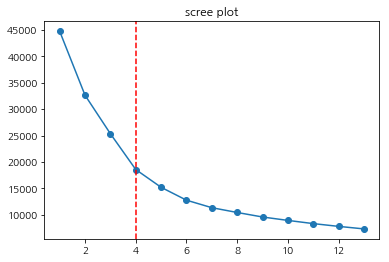

Counter({2: 3603, 1: 3478, 0: 1486, 3: 383})
kmeans clustering 실루엣 점수: 0.4216823443067045


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from collections import Counter

df.drop(columns=['CUST_ID'], inplace=True)
sc = StandardScaler()
s_df = sc.fit_transform(df)

ee = []
# kmeans의 scree plot
for i in range(1, 14):
    km = KMeans(n_clusters=i).fit(s_df)
    ee.append(km.inertia_) #오차제곱합 

plt.plot(list(range(1, 14)), ee, marker='o')
plt.title('scree plot')
plt.axvline(x=4, color='r', ls='--')
plt.show()

model1 = KMeans(n_clusters=4, random_state=0).fit(s_df)

rs1 = model1.labels_ #군집반환
print(f"{Counter(rs1)}")
print(f"kmeans clustering 실루엣 점수: {silhouette_score(s_df, rs1)}") #x, y

eps 0.6 잡음 수 : 290
eps 0.7 잡음 수 : 219
eps 0.8 잡음 수 : 170
eps 0.92 잡음 수 : 121


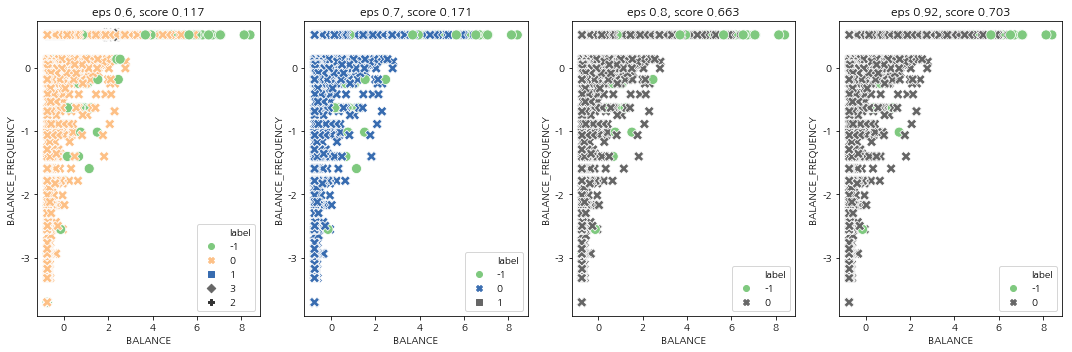

Counter({0: 8539, 1: 7})
dbscan clustering 실루엣 점수: 0.37030547480431164


In [77]:
#dbscan 

s_df = pd.DataFrame(s_df, columns=df.columns)

eps_list = [0.6, 0.7, 0.8, 0.92]

fig, ax = plt.subplots(1, 4, figsize=(15, 5))

for i, eps in enumerate(eps_list):
    db = DBSCAN(eps=eps, min_samples=5).fit(s_df)
    tmp = s_df.copy()
    tmp['label'] = db.labels_
    sns.scatterplot(x='BALANCE', y='BALANCE_FREQUENCY', data=tmp, hue='label', style='label', s=100, ax=ax[i], palette='Accent')
    e_idx = list(np.where(db.labels_ == -1)[0]) #잡음(레이블) 인덱스
    print(f"eps {eps} 잡음 수 : {len(e_idx)}")
    o_score = silhouette_score(s_df, db.labels_) #원본데이터 스코어(잡음포함)
    ax[i].set_title(f"eps {eps}, score {o_score:.3f}")
plt.tight_layout()
plt.show()

model2 = DBSCAN(eps=0.6, min_samples=10).fit(s_df)
rs2 = model2.labels_ #군집반환
mask = list(np.where(rs2 != -1)[0]) #잡음 제거
rs2 = rs2[mask]
print(f"{Counter(rs2)}")
print(f"dbscan clustering 실루엣 점수: {silhouette_score(s_df.iloc[mask], rs2)}") #x, y

2. 두 모델을 비교하고, 더 타당한 모델을 선택하시오.

실루엣 점수는 dbscan이 0.37로 kmeans에 비해 낮으며, 분류한 레이블 개수와 분포를 보아도 제대로 분류되었다고 보기 어렵다.  
대부분의 데이터를 0 클러스터로 분류, 단지 7개의 클러스터만 1로 분류하였기 때문이다. 
따라서 kmeans clustering을 채택한다.

3. 선택한 모델로 생성한 군집들의 고객 특성을 분석하시오.

In [78]:
df['label'] = rs1
for i in range(1, 3):
    print(f"<label {i}>")
    display(df[df['label'] == i].describe().T)

<label 1>


,count,mean,std,min,25%,50%,75%,max
BALANCE,3478.0,2397.403425,2281.640947,0.488050,924.568166,1603.208588,3098.06151,16304.88925
BALANCE_FREQUENCY,3478.0,0.975133,0.064168,0.545455,1.000000,1.000000,1.00000,1.00000
PURCHASES,3478.0,230.473778,465.863497,0.000000,0.000000,0.525000,255.61000,4900.00000
PURCHASES_FREQUENCY,3478.0,0.132477,0.179065,0.000000,0.000000,0.083333,0.25000,1.00000
PURCHASES_TRX,3478.0,2.381541,3.845772,0.000000,0.000000,1.000000,4.00000,34.00000
label,3478.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.00000


<label 2>


,count,mean,std,min,25%,50%,75%,max
BALANCE,3603.0,1084.461729,1450.187424,0.734665,111.846337,483.402486,1464.953818,11734.26656
BALANCE_FREQUENCY,3603.0,0.967770,0.076057,0.454545,1.000000,1.000000,1.000000,1.00000
PURCHASES,3603.0,1316.878437,1166.212480,8.400000,463.155000,938.200000,1840.655000,8591.31000
PURCHASES_FREQUENCY,3603.0,0.872380,0.160581,0.250000,0.750000,0.916667,1.000000,1.00000
PURCHASES_TRX,3603.0,21.972245,14.675873,0.000000,12.000000,17.000000,28.000000,98.00000
label,3603.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.00000


평균과 중위수를 기준으로 각 레이블 별 featuer의 특성을 분석한다.  
- 1번 군집: 3개 군집 중 가장 적은 비율을 차지하며, 가장 은행잔고가 적고 중간 수준의 구매활동을 보인다.   
  구매계좌잔액 업데이트 빈도가 낮으며, 구매액은 중간 수준이다. 
- 2번 군집: 3개 군집 중 가장 부유한 집단이며, 구매를 거의 하지 않는다. 50% 이상의 사람들이 아예 구매를 하지 않으며,  
  구매빈도 또한 낮다.
- 3번 군집: 중위 수준의 경제력을 가지고 있으며, 가장 활발한 구매활동을 한다. 

4. 고객특성이 다음과 같다면 어느 군집으로 분류하는 것이 타당한지 서술하시오.
- balance: 3000, balance_freq: 1, purchase: 6000, 구매빈도지수: 1, 구매거래건수: 100

In [79]:
model1.predict(sc.transform([[3000, 1, 6000, 1, 100]]))

array([3])

은행잔고가 상당하며 구매계좌잔액이 자주 업데이트되고, 구매액수가 높으며, 활발한 구매활동을 하므로 군집 3에 가깝다.

5. 각 군집들을 대상으로 마케팅 전략을 수립하시오.

2번 군집에 해당하는 **고잔고·저구매 고객(high balance, low purchase)**은 중요한 잠재 VIP 고객층이다.  
전체의 약 40%를 차지하며, 자산 기반이 탄탄하므로 충성고객화 시 높은 매출 향상을 기대할 수 있다.  
기존 마케팅이 구매를 유도하는 데 효과적이지 않았다는 점에서 목표 마케팅 전략 재수립이 필요함

| 전략 요소             | 목적 및 기대 효과                                     |
| ----------------- | ---------------------------------------------- |
| VIP 등급제 / 멤버십 강화  | 등급 상승 유도로 반복 구매 유도 → 충성 고객 확보 및 고객 유지율 향상      |
| 개인 맞춤형 상품 추천/프로모션 | 구매력이 낮은 고객의 관심 있는 상품 및 커뮤니케이션 채널 통한 구매 전환 유도   |
| 광고 매체 및 메시지 조정    | 고급, 가치 중심 커뮤니케이션으로 고객 감성 자극 및 브랜드 이미지 강화       |
| 가치 기반 가격/혜택 설계    | 가격 민감도 낮은 고객에 대한 고부가 혜택 제공 → 장기 매출 증대 및 잔존율 강화 |
